## 1. Imports

In [2]:
import time
import pygad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fitness import convertir_cromosoma, calcular_fitness

## 2. Configuración del experimento

In [3]:
TARGET_FITNESS = 53.25
EJECUCIONES    = 30

instancias = [
    {"nombre": "Instancia 1 (NORMAL)",    "poblacion": 100, "mutacion": 0.05},
    {"nombre": "Instancia 2 (MUTACIÓN)",  "poblacion": 100, "mutacion": 0.01},
    {"nombre": "Instancia 3 (POBLACIÓN)", "poblacion":  50, "mutacion": 0.05},
]

## 3. Construcción del AG (PyGAD)

In [4]:
def construir_ga(poblacion, mutacion):
    

    def fitness_fn(ga_instance, cromosoma, idx):
        return calcular_fitness(convertir_cromosoma(cromosoma))

    def on_generation(ga):
        if not hasattr(ga, "hist_mejor"):
            ga.hist_mejor = []
        ga.hist_mejor.append(float(np.max(ga.last_generation_fitness)))

    return pygad.GA(
        sol_per_pop          = poblacion,
        num_genes            = 50,
        gene_type            = int,
        gene_space           = range(0, 20),
        fitness_func         = fitness_fn,
        parent_selection_type= "tournament",
        K_tournament         = 3,
        keep_elitism         = 5,
        crossover_type       = "two_points",
        num_parents_mating   = poblacion // 2,
        mutation_type        = "random",
        mutation_probability = mutacion,
        num_generations      = 500,
        stop_criteria        = ["reach_53.25", "saturate_50"],
        on_generation        = on_generation,
    )

## 4. Ejecución de las 30 corridas por instancia

In [5]:
def ejecutar_instancia(inst):
  
    gens_list, tiempos_list, hits = [], [], 0

    for ejecucion in range(1, EJECUCIONES + 1):
        ga = construir_ga(inst["poblacion"], inst["mutacion"])
        t0 = time.time()
        ga.run()
        duracion = time.time() - t0

        _, fitness, _ = ga.best_solution()
        gens_list.append(ga.generations_completed)
        tiempos_list.append(round(duracion, 4))
        if float(fitness) >= TARGET_FITNESS:
            hits += 1

        print(f"  [{ejecucion:>2}/{EJECUCIONES}] gen={ga.generations_completed:>3}  "
              f"t={duracion:.3f}s  fit={fitness:.4f}")

    return {
        "nombre"  : inst["nombre"],
        "gens"    : gens_list,
        "tiempos" : tiempos_list,
        "hit_rate": round(hits / EJECUCIONES * 100, 1),
    }


# --- Ejecutar todas las instancias ---
resultados = []
for inst in instancias:
    print(f"\n{'='*52}")
    print(f"  Ejecutando: {inst['nombre']}")
    print(f"  Población={inst['poblacion']}  Mutación={inst['mutacion']}")
    print(f"{'='*52}")
    resultados.append(ejecutar_instancia(inst))


  Ejecutando: Instancia 1 (NORMAL)
  Población=100  Mutación=0.05
  [ 1/30] gen=  8  t=0.109s  fit=53.2500
  [ 2/30] gen=  5  t=0.068s  fit=53.2500
  [ 3/30] gen= 18  t=0.236s  fit=53.2500
  [ 4/30] gen=  7  t=0.089s  fit=53.2500
  [ 5/30] gen= 10  t=0.129s  fit=53.2500
  [ 6/30] gen=  4  t=0.054s  fit=53.2500
  [ 7/30] gen= 11  t=0.152s  fit=53.2500
  [ 8/30] gen=  4  t=0.057s  fit=53.2500
  [ 9/30] gen=  4  t=0.052s  fit=53.2500
  [10/30] gen= 18  t=0.218s  fit=53.2500
  [11/30] gen= 10  t=0.132s  fit=53.2500
  [12/30] gen=  6  t=0.080s  fit=53.2500
  [13/30] gen=  8  t=0.099s  fit=53.2500
  [14/30] gen= 10  t=0.126s  fit=53.2500
  [15/30] gen=  4  t=0.054s  fit=53.2500
  [16/30] gen=  9  t=0.112s  fit=53.2500
  [17/30] gen= 10  t=0.130s  fit=53.2500
  [18/30] gen=  7  t=0.094s  fit=53.2500
  [19/30] gen=  5  t=0.065s  fit=53.2500
  [20/30] gen= 18  t=0.214s  fit=53.2500
  [21/30] gen= 17  t=0.204s  fit=53.2500
  [22/30] gen= 11  t=0.165s  fit=53.2500
  [23/30] gen= 19  t=0.231s  fi

## 5. Tabla resumen comparativa

In [6]:
filas = [
    {
        "Instancia"          : r["nombre"],
        "Hit Rate (%)"       : r["hit_rate"],
        "Prom. Generaciones" : round(np.mean(r["gens"]),    1),
        "Min. Generaciones"  : int(np.min(r["gens"])),
        "Std. Generaciones"  : round(np.std(r["gens"]),     1),
        "Prom. Tiempo (s)"   : round(np.mean(r["tiempos"]), 3),
        "Min. Tiempo (s)"    : round(np.min(r["tiempos"]),  3),
    }
    for r in resultados
]

df = pd.DataFrame(filas).set_index("Instancia")
df

,Hit Rate (%),Prom. Generaciones,Min. Generaciones,Std. Generaciones,Prom. Tiempo (s),Min. Tiempo (s)
Instancia,,,,,,
Instancia 1 (NORMAL),100.0,9.7,3,4.9,0.124,0.045
Instancia 2 (MUTACIÓN),100.0,6.4,2,2.2,0.075,0.031
Instancia 3 (POBLACIÓN),100.0,9.2,2,3.2,0.058,0.018


## 6. Gráficos comparativos

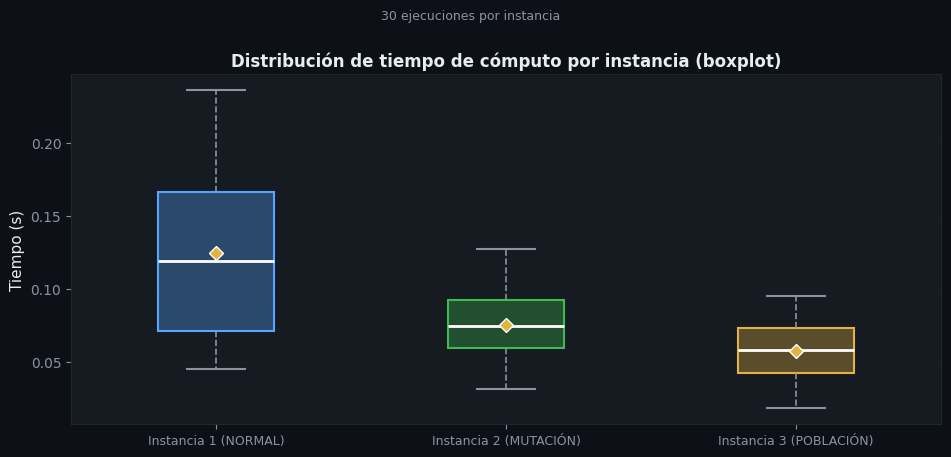

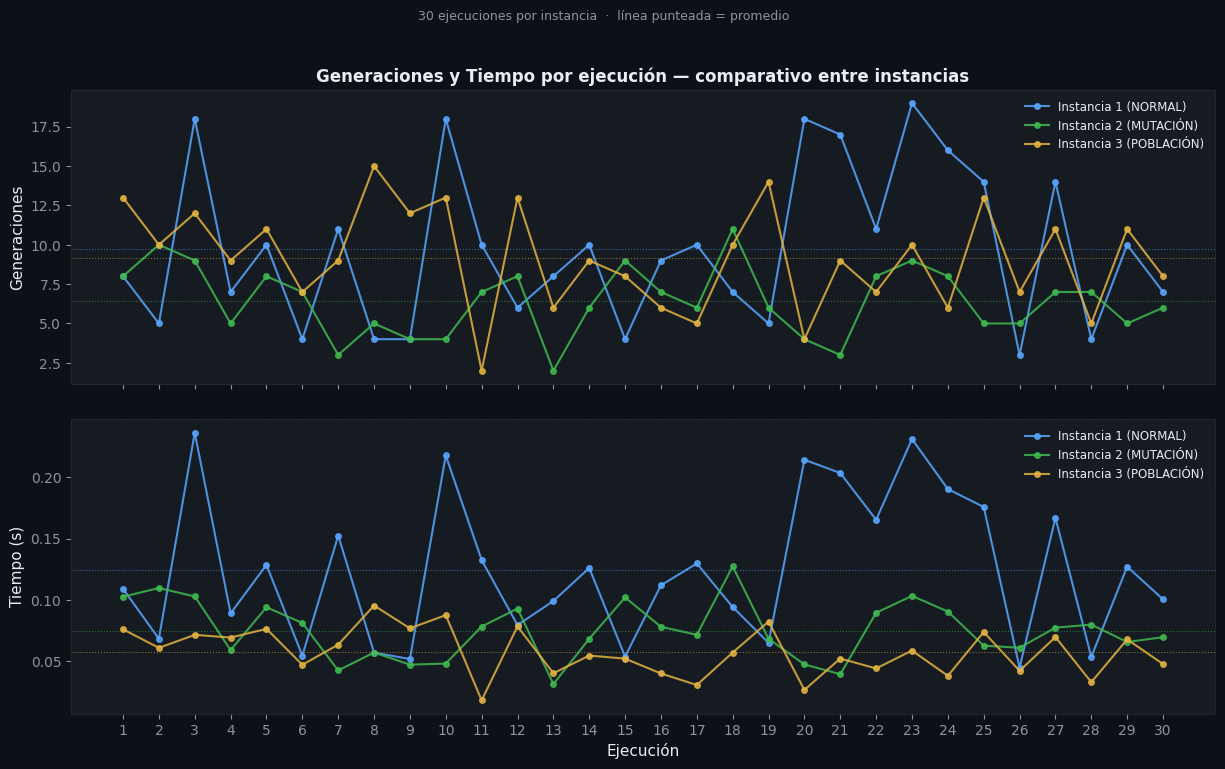

In [7]:
# ── Paleta oscura ──────────────────────────────────────────────────────────────────────────
BG      = "#0d1117"
AX_BG   = "#161b22"
GRID    = "#21262d"
TEXT    = "#e6edf3"
MUTED   = "#8b949e"
COLORES = ["#58a6ff", "#3fb950", "#e3b341"]

plt.rcParams.update({
    "figure.facecolor": BG,   "axes.facecolor": AX_BG,
    "axes.edgecolor":   GRID, "axes.labelcolor": TEXT,
    "axes.titlecolor":  TEXT, "xtick.color": MUTED,
    "ytick.color":      MUTED, "text.color": TEXT,
    "grid.color":       GRID, "legend.facecolor": AX_BG,
    "legend.edgecolor": GRID, "font.size": 10,
})

nombres   = [r["nombre"]  for r in resultados]
ejes      = np.arange(1, EJECUCIONES + 1)


# ── Boxplot de tiempo de cómputo por instancia ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
fig.subplots_adjust(left=0.10, right=0.97, top=0.85, bottom=0.15)

datos_tiem = [r["tiempos"] for r in resultados]
bp = ax.boxplot(
    datos_tiem, patch_artist=True, widths=0.4,
    showmeans=True, showfliers=True,
    boxprops    = dict(linewidth=1.5),
    medianprops = dict(color="white", linewidth=2),
    meanprops   = dict(marker="D", markerfacecolor="#e3b341",
                       markeredgecolor="white", markersize=7),
    whiskerprops= dict(color=MUTED, linewidth=1.2, linestyle="--"),
    capprops    = dict(color=MUTED, linewidth=1.5),
    flierprops  = dict(marker="o", markerfacecolor="#f78166",
                       markeredgecolor="white", markersize=5, alpha=0.8),
)
for patch, color in zip(bp["boxes"], COLORES):
    patch.set_facecolor(color + "55")
    patch.set_edgecolor(color)

ax.set_xticks(range(1, len(nombres) + 1))
ax.set_xticklabels(nombres, fontsize=9)
ax.set_ylabel("Tiempo (s)", fontsize=11)
ax.set_title("Distribución de tiempo de cómputo por instancia (boxplot)", fontsize=12, fontweight="bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
fig.suptitle(f"{EJECUCIONES} ejecuciones por instancia", color=MUTED, fontsize=9)
plt.show()


# ── Líneas — Generaciones y Tiempo por ejecución (2 subplots) ────────────────────
fig4, (ax4a, ax4b) = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG,
                                   sharex=True)
fig4.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.10, hspace=0.12)

for r, color in zip(resultados, COLORES):
    ax4a.plot(ejes, r["gens"], color=color, linewidth=1.5,
              marker="o", markersize=4, alpha=0.85, label=r["nombre"])
    ax4a.axhline(np.mean(r["gens"]), color=color, linewidth=0.8,
                 linestyle=":", alpha=0.55)

    ax4b.plot(ejes, r["tiempos"], color=color, linewidth=1.5,
              marker="o", markersize=4, alpha=0.85, label=r["nombre"])
    ax4b.axhline(np.mean(r["tiempos"]), color=color, linewidth=0.8,
                 linestyle=":", alpha=0.55)

ax4a.set_ylabel("Generaciones", fontsize=11)
ax4a.set_title("Generaciones y Tiempo por ejecución — comparativo entre instancias",
               fontsize=12, fontweight="bold")
ax4a.legend(loc="upper right", fontsize=8.5, framealpha=0.35)
ax4a.grid(True, linestyle="--", alpha=0.30)

ax4b.set_xlabel("Ejecución", fontsize=11)
ax4b.set_ylabel("Tiempo (s)", fontsize=11)
ax4b.set_xticks(ejes)
ax4b.legend(loc="upper right", fontsize=8.5, framealpha=0.35)
ax4b.grid(True, linestyle="--", alpha=0.30)

fig4.suptitle(f"{EJECUCIONES} ejecuciones por instancia  ·  línea punteada = promedio",
              color=MUTED, fontsize=9)
plt.show()


## 7. Curva de convergencia — Instancia Normal (1 ejecución)

Generaciones totales : 11
Tiempo total         : 0.1394s
Convergencia         : gen 11  |  ~0.1394s


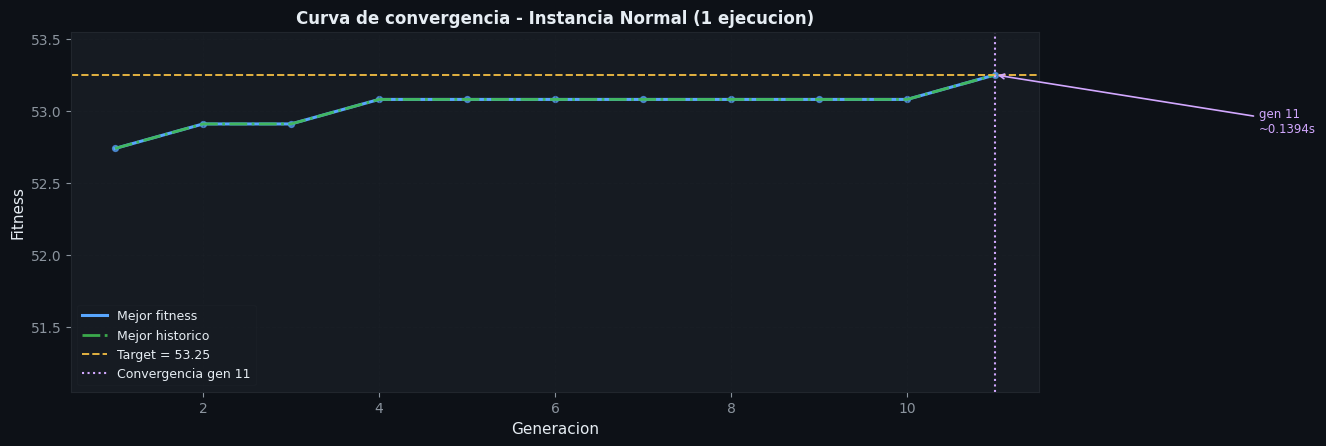

In [8]:
# Una sola ejecucion: muestra el fitness maximo por generacion
# Sin criterio 'reach' para que corra todas las generaciones y se vea la curva completa

import time as _time

def on_gen_conv(ga):
    if not hasattr(ga, 'hist_mejor'):
        ga.hist_mejor = []
    if not hasattr(ga, 'hist_prom'):
        ga.hist_prom = []
    if not hasattr(ga, 'hist_std'):
        ga.hist_std = []

    fitness = np.array(ga.last_generation_fitness)
    ga.hist_mejor.append(float(np.max(fitness)))
    ga.hist_prom.append(float(np.mean(fitness)))
    ga.hist_std.append(float(np.std(fitness)))

# Llamada usando los parámetros de la instancia 0
inst = instancias[0]
ga_conv = construir_ga(inst['poblacion'], inst['mutacion'])

# Inyectamos tu callback para capturar promedio y std
ga_conv.on_generation = on_gen_conv

t0 = _time.time()
ga_conv.run()
t_total = _time.time() - t0

hist = ga_conv.hist_mejor
gens = list(range(1, len(hist) + 1))

# Generacion en que se alcanzo el target por primera vez
gen_conv = next((i + 1 for i, v in enumerate(hist) if v >= TARGET_FITNESS), None)
t_conv   = round(t_total * gen_conv / len(hist), 4) if gen_conv else None

print(f'Generaciones totales : {ga_conv.generations_completed}')
print(f'Tiempo total         : {t_total:.4f}s')
if gen_conv:
    print(f'Convergencia         : gen {gen_conv}  |  ~{t_conv}s')


# -- Grafico mejorado ---------------------------------------------------------
fig_c, ax_c = plt.subplots(figsize=(11, 5), facecolor=BG)
fig_c.subplots_adjust(left=0.09, right=0.97, top=0.85, bottom=0.13)

# Datos
mejor = np.array(ga_conv.hist_mejor)
prom  = np.array(ga_conv.hist_prom)
std   = np.array(ga_conv.hist_std)

# Mejor fitness
ax_c.plot(gens, mejor, color='#58a6ff', linewidth=2.2, label='Mejor fitness')

# Puntos individuales
ax_c.scatter(gens, mejor, color='#58a6ff', s=18, alpha=0.65)


# Mejor historico acumulado
best_so_far = np.maximum.accumulate(mejor)
ax_c.plot(gens, best_so_far, color='#3fb950', linewidth=2, alpha=0.9, linestyle='-.', label='Mejor historico')

# Target
ax_c.axhline(TARGET_FITNESS, color='#e3b341', linewidth=1.4, linestyle='--', label=f'Target = {TARGET_FITNESS}')

# Convergencia
if gen_conv:
    ax_c.axvline(gen_conv, color='#d2a8ff', linewidth=1.5, linestyle=':', label=f'Convergencia gen {gen_conv}')
    ax_c.annotate(f'gen {gen_conv}\n~{t_conv}s',
                  xy=(gen_conv, mejor[gen_conv - 1]),
                  xytext=(gen_conv + max(len(hist) * 0.03, 3), mejor[gen_conv - 1] - 0.4),
                  color='#d2a8ff', fontsize=8.5,
                  arrowprops=dict(arrowstyle='->', color='#d2a8ff', lw=1.2))

# Zoom eje Y
ymin = min(prom - std) - 0.3
ymax = max(mejor) + 0.3
ax_c.set_ylim(ymin, ymax)

ax_c.set_xlabel('Generacion', fontsize=11)
ax_c.set_ylabel('Fitness', fontsize=11)
ax_c.set_title('Curva de convergencia - Instancia Normal (1 ejecucion)', fontsize=12, fontweight='bold')
ax_c.grid(True, linestyle='--', alpha=0.25)
legend = ax_c.legend(fontsize=9, framealpha=0.35)
legend.get_frame().set_facecolor('#161b22')

plt.show()


### Análisis estadístico

#### Evaluación de normalidad

In [ ]:
from scipy import stats

# Tiempos
stat, p_valor = stats.shapiro(resultados[0]["tiempos"]) # Se comprobó con el resto de los tiempos (0, 1 y 2)

if p_valor < 0.05:
    print("Los datos de tiempo NO son normales (se rechaza H0)")
else:
    print("Los datos de tiempo son normales (NO se rechaza H0)")
    
# Generaciones
stat, p_valor = stats.shapiro(resultados[0]["gens"])

if p_valor < 0.05:
    print("Los datos de generaciones NO son normales (se rechaza H0)")
else:
    print("Los datos de generaciones son normales (NO se rechaza H0)")

Los datos de tiempo son normales (NO se rechaza H0)
Los datos de generaciones NO son normales (se rechaza H0)


#### Validación de diferencia significativa

In [ ]:
from IPython.display import display

# --- FUNCIÓN DE ESTILIZADO INTELIGENTE ---
def estilo_p_valores_oscuro(val):
    if val == 1.0:
        # Diagonal - Gris 
        return 'background-color: #212529; color: #adb5bd; font-style: italic; border: 1px solid #3d4248;'
    elif val < 0.05:
        # Significativo (p < 0.05) - Verde
        return 'background-color: #0f4c2c; color: #69f0ae; font-weight: bold; border: 1px solid #1b5e3a;'
    else:
        # No significativo - Rojo
        return 'background-color: #5c1e24; color: #ff9fa6; border: 1px solid #842e37;'

# Configuración CSS
estilos_tabla_oscuro = [
    {
        'selector': 'th',
        'props': [
            ('background-color', '#1e2125'),
            ('color', '#ffffff'),
            ('font-family', 'sans-serif'),
            ('padding', '12px 16px'),
            ('border', '1px solid #3d4248'),
            ('text-align', 'center'),
            ('font-weight', 'bold')
        ]
    }
]

def mostrar_matriz_estilizada(matriz, titulo):
    styler = matriz.style
    
    # Fondo oscuro
    styler = styler.set_properties(**{
        'text-align': 'center',
        'padding': '12px 18px',
        'font-family': 'sans-serif',
        'font-size': '1rem',
        'background-color': '#1a1d20',
        'color': '#f8f9fa',
        'border': '1px solid #343a40'
    })
    
    # --- DETECCIÓN CUADRADA ---
    es_matriz_cuadrada = (list(matriz.index) == list(matriz.columns))
    
    # Identificar si hay alguna columna de p-valor por nombres estándar
    columnas_p_detectadas = [
        col for col in matriz.columns 
        if str(col).lower() in ['pval', 'p_unc', 'p-val', 'p-value', 'p_value', 'p_valor', 'p-valor']
    ]
    
    # Aplicar color dinámico
    if es_matriz_cuadrada:
        styler = styler.map(estilo_p_valores_oscuro) if hasattr(styler, 'map') else styler.applymap(estilo_p_valores_oscuro)
    elif columnas_p_detectadas:
        styler = styler.map(estilo_p_valores_oscuro, subset=columnas_p_detectadas) if hasattr(styler, 'map') else styler.applymap(estilo_p_valores_oscuro, subset=columnas_p_detectadas)
        
    # 3. Formateo de decimales
    formatos = {}
    for col in matriz.columns:
        if matriz[col].dtype in ['float64', 'float32']:
            if es_matriz_cuadrada or col in columnas_p_detectadas:
                formatos[col] = lambda x: f"{x:.4e}" if x < 0.001 else f"{x:.6f}"
            else:
                formatos[col] = "{:.4f}"
        
    styler = (styler
        .format(formatos)
        .set_caption(f"<b style='font-size: 1.2rem; color: #ffffff; font-family: sans-serif; display: block; padding-bottom: 12px;'>{titulo}</b>")
        .set_table_styles(estilos_tabla_oscuro)
    )
    display(styler)


#### Tiempo (que tiene forma normal)

In [ ]:
from scipy import stats

# 1. Test de Levene (Homogeneidad de varianzas)
stat_levene, p_levene = stats.levene(resultados[0]["tiempos"], resultados[1]["tiempos"], resultados[2]["tiempos"])

if p_levene < 0.05:
    print("Las varianzas NO son homogéneas. Según la cátedra, usar test de Welch.")

else:
    print("Las varianzas SON homogéneas. Se procede con ANOVA.")
    
    # 2. Test ANOVA
    stat_anova, p_anova = stats.f_oneway(resultados[0]["tiempos"], resultados[1]["tiempos"], resultados[2]["tiempos"])
    print(f"P-valor del ANOVA: {p_anova}")
    
    if p_anova < 0.05:
        print("Hay diferencias significativas en el tiempo de las instancias.")
    else:
        print("No hay diferencias significativas en el tiempo.")
        

import pingouin as pg
# 1. Pingouin necesita que los datos estén en un DataFrame
datos_welch = pd.DataFrame({
    'Tiempo': list(resultados[0]["tiempos"]) + list(resultados[1]["tiempos"]) + list(resultados[2]["tiempos"]),
    'Instancia': ['Instancia_1']*30 + ['Instancia_2']*30 + ['Instancia_3']*30
})

# 2. Ejecutar el ANOVA de Welch
test_welch = pg.welch_anova(dv='Tiempo', between='Instancia', data=datos_welch)
mostrar_matriz_estilizada(test_welch, "Resultado del Test de Welch")

# 3. Test Post-Hoc (Games-Howell) para ver qué instancias son diferentes entre sí
posthoc_tiempos = pg.pairwise_gameshowell(dv='Tiempo', between='Instancia', data=datos_welch)

df_posthoc_mostrar = posthoc_tiempos[['A', 'B', 'pval']].copy()
mostrar_matriz_estilizada(df_posthoc_mostrar, "Comparación Post-Hoc (Games-Howell)")

Las varianzas NO son homogéneas. Según la cátedra, usar test de Welch.


,Source,ddof1,ddof2,F,p_unc,np2
0,Instancia,2,52.9277,18.8602,6.5469e-07,0.3580


,A,B,pval
0,Instancia_1,Instancia_2,3.9435e-04
1,Instancia_1,Instancia_3,3.5348e-06
2,Instancia_2,Instancia_3,0.008146


#### Generaciones

In [ ]:
import scikit_posthocs as sp

# --- ANÁLISIS DE GENERACIONES ---
nombres_instancias = [res["nombre"] for res in resultados]
estadistico, p_valor_kruskal = stats.kruskal(*(res["gens"] for res in resultados))

print(f"P-valor de Kruskal-Wallis (Generaciones): {p_valor_kruskal:.4e}")
if p_valor_kruskal < 0.05:
    print("-> Existen diferencias sobre generaciones estadísticamente significativas entre las 3 instancias.")
else:
    print("-> No hay evidencia suficiente para decir que una instancia es mejor que otra en generaciones.")

generaciones_experimento = [res["gens"] for res in resultados]

# Test post-hoc de Dunn y asignación de nombres
matriz_generaciones = sp.posthoc_dunn(generaciones_experimento, p_adjust='holm')
matriz_generaciones.columns = nombres_instancias
matriz_generaciones.index = nombres_instancias

# Renderizado premium de Generaciones
mostrar_matriz_estilizada(matriz_generaciones, "Matriz de p-valores de GENERACIONES Post-Hoc (Dunn-Holm)")


P-valor de Kruskal-Wallis (Generaciones): 2.7045e-03
-> Existen diferencias sobre generaciones estadísticamente significativas entre las 3 instancias.


,Instancia 1 (NORMAL),Instancia 2 (MUTACIÓN),Instancia 3 (POBLACIÓN)
Instancia 1 (NORMAL),1.000000,0.010056,0.748998
Instancia 2 (MUTACIÓN),0.010056,1.000000,0.005331
Instancia 3 (POBLACIÓN),0.748998,0.005331,1.000000
